# 06 · Self-critical sequence training (SCST)

Cross-entropy trains the decoder to predict the next *reference* word, but it is judged on caption-level CIDEr. SCST closes that gap with reinforcement learning: sample 5 captions per image, score each with CIDEr-D, and raise the probability of those that beat the mean of the other 4 (Rennie et al. 2017; baseline from Luo 2020).

The reward uses training-set document frequencies and an explicit `<eos>`, so captions that stop mid-phrase earn nothing. Adam at 2e-5 for 15 epochs, identical for both decoders, starting from each one's cross-entropy checkpoint (epoch 0 below).

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from pycocoevalcap.cider.cider import Cider
from torch.utils.data import DataLoader

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src import viz
from src.dataset import ImageFeatureDataset, load_processed, reference_captions, split_images, tokenize
from src.decoding import generate_captions
from src.models import load_checkpoint
from src.scst import CiderD, scst_fit
from src.train import run_experiment
from src.utils import caption_scores, set_seed

viz.setup_style()
IMAGE_DIR = ROOT / "data" / "raw" / "Images"
CKPT = ROOT / "checkpoints"
RESULTS = ROOT / "results" / "scst"
RESULTS.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda")
features, images, vocab = load_processed(ROOT / "data" / "processed")
train_images, val_images = split_images(images, "train"), split_images(images, "val")
val_image_loader = DataLoader(ImageFeatureDataset(features, val_images), batch_size=256)
val_refs = reference_captions(val_images)

SCST_CONFIG = dict(epochs=15, lr=2e-5, batch_images=50, n_samples=5, max_len=20, grad_clip=1.0, seed=42)
DECODERS = {"Transformer": "transformer", "LSTM + attention": "lstm"}
missing = [f"{slug}_xe.pt" for slug in DECODERS.values() if not (CKPT / f"{slug}_xe.pt").exists()]
assert not missing, f"train the cross-entropy models first (notebooks 02 and 05); missing: {missing}"
display(viz.table(pd.DataFrame([SCST_CONFIG]), caption="SCST configuration (same for both decoders)", formats={"lr": "{:.0e}"}))

epochs,lr,batch_images,n_samples,max_len,grad_clip,seed
15,2e-05,50,5,20,1.000,42


## Reward check
Our CIDEr-D must match `pycocoevalcap` exactly when both use the same references.

In [2]:
rng = np.random.default_rng(0)
held_out = {f: rng.integers(5) for f in val_refs}
hyps = {f: refs[held_out[f]] for f, refs in val_refs.items()}
others = {f: [r for i, r in enumerate(refs) if i != held_out[f]] for f, refs in val_refs.items()}
scorer = CiderD({f: [r.split() for r in rs] for f, rs in others.items()})
ours = np.mean([scorer.score(hyps[f].split(), f) for f in others])
theirs, _ = Cider().compute_score(others, {f: [h] for f, h in hyps.items()})
display(viz.table(pd.DataFrame([{"implementation": "src.scst.CiderD", "CIDEr-D": ours},
                                {"implementation": "pycocoevalcap Cider", "CIDEr-D": theirs}]),
                  precision=6, caption="Held-out human captions scored against the other 4 references (val)"))
assert abs(ours - theirs) < 1e-6

implementation,CIDEr-D
src.scst.CiderD,0.635346
pycocoevalcap Cider,0.635346


## Fine-tuning
**Reward** is the mean CIDEr-D of the sampled training captions; val metrics use greedy decoding. Epoch 0 is the cross-entropy starting point.

In [3]:
histories = {}
for label, slug in DECODERS.items():
    ckpt_path = CKPT / f"{slug}_scst.pt"
    live = viz.LiveTable(
        f"SCST: {label}",
        {"epoch": "epoch", "train_reward": "reward", "sample_len": "sample length", "val_bleu4": "val BLEU-4",
         "val_cider": "val CIDEr", "seconds": "sec"},
        maximize=["val_cider"], formats={"seconds": "{:.0f}", "train_reward": "{:.3f}", "sample_len": "{:.1f}"},
    )

    def build(slug=slug):
        return load_checkpoint(CKPT / f"{slug}_xe.pt", device)[0]

    def train_fn(model, ckpt_path=ckpt_path, slug=slug, live=live):
        cfg = {k: v for k, v in SCST_CONFIG.items() if k != "seed"}
        return scst_fit(model, features, train_images, vocab, device, val_image_loader, val_refs,
                        ckpt_path=ckpt_path, on_epoch_end=live,
                        run_config={"scst": SCST_CONFIG, "init": f"{slug}_xe.pt"}, **cfg)

    history, cached = run_experiment(label, build, train_fn, ckpt_path=ckpt_path,
                                     history_path=RESULTS / slug / "history.json", seed=SCST_CONFIG["seed"])
    if cached:
        live(history)
    histories[label] = history

epoch,reward,sample length,val BLEU-4,val CIDEr,sec
0,–,–,0.231,0.476,0
1,0.442,10.2,0.252,0.536,187
2,0.569,10.2,0.258,0.553,155
3,0.619,10.4,0.252,0.544,152
4,0.655,10.3,0.254,0.546,149
5,0.685,10.3,0.250,0.549,146
6,0.711,10.4,0.249,0.551,147
7,0.735,10.3,0.242,0.544,146
8,0.757,10.4,0.248,0.549,147
9,0.777,10.4,0.248,0.545,146


epoch,reward,sample length,val BLEU-4,val CIDEr,sec
0,–,–,0.212,0.463,0
1,0.483,10.5,0.243,0.498,104
2,0.601,10.3,0.243,0.513,88
3,0.649,10.2,0.247,0.520,83
4,0.683,10.2,0.246,0.533,83
5,0.714,10.2,0.244,0.531,82
6,0.739,10.2,0.246,0.536,82
7,0.763,10.3,0.248,0.548,80
8,0.783,10.2,0.251,0.538,79
9,0.804,10.3,0.247,0.536,81


## Training curves

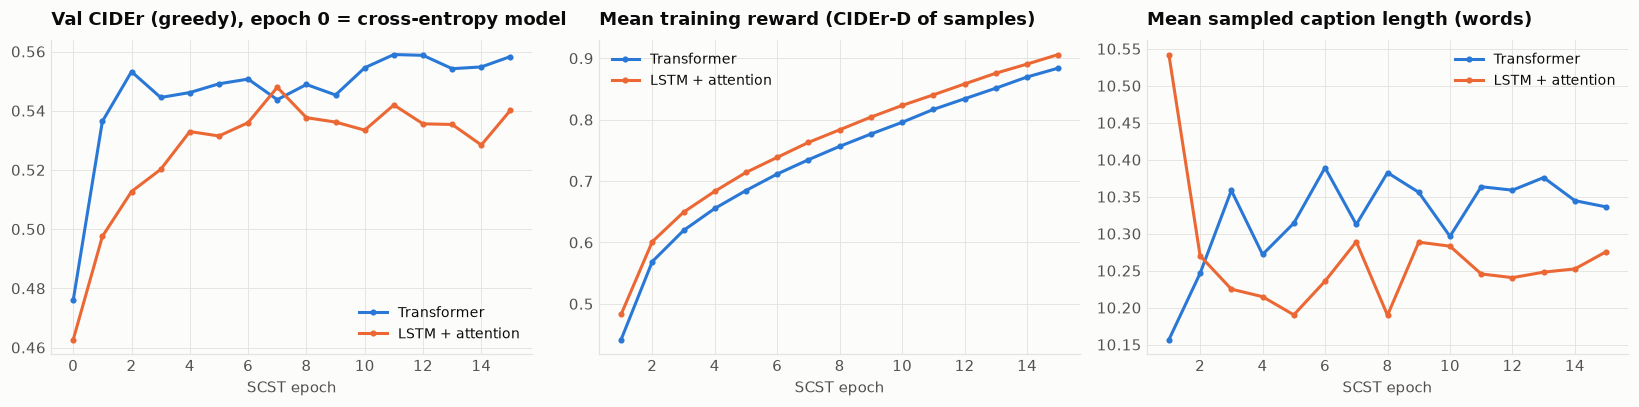

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
for label, hist in histories.items():
    h = pd.DataFrame(hist)
    axes[0].plot(h.epoch, h.val_cider, marker="o", ms=3, label=label)
    axes[1].plot(h.epoch[1:], h.train_reward[1:], marker="o", ms=3, label=label)
    axes[2].plot(h.epoch[1:], h.sample_len[1:], marker="o", ms=3, label=label)
axes[0].set(title="Val CIDEr (greedy), epoch 0 = cross-entropy model", xlabel="SCST epoch")
axes[1].set(title="Mean training reward (CIDEr-D of samples)", xlabel="SCST epoch")
axes[2].set(title="Mean sampled caption length (words)", xlabel="SCST epoch")
for ax in axes:
    ax.legend()
plt.tight_layout()
plt.savefig(RESULTS / "scst_curves.png")
plt.show()

## Cross-entropy vs SCST (val, greedy)
**ends mid-phrase** = the caption ends in a function word; **repeats a phrase** = some word pair occurs twice.

In [5]:
FUNCTION_WORDS = {"a", "an", "the", "of", "in", "on", "with", "and", "at", "to", "is", "are", "his", "her", "their"}
train_caption_set = {" ".join(tokenize(c)) for img in train_images for c in img["captions"]}


def repeats_phrase(text):
    words = text.split()
    bigrams = list(zip(words, words[1:]))
    return len(bigrams) != len(set(bigrams))


def caption_stats(caps):
    texts = list(caps.values())
    return {
        "avg words": np.mean([len(t.split()) for t in texts]),
        "ends mid-phrase": np.mean([bool(t) and t.split()[-1] in FUNCTION_WORDS for t in texts]),
        "repeats a phrase": np.mean([repeats_phrase(t) for t in texts]),
        "distinct captions": len(set(texts)) / len(texts),
        "copied from train": np.mean([t in train_caption_set for t in texts]),
        "vocabulary used": len({w for t in texts for w in t.split()}),
    }


rows, val_caps = [], {}
for label, slug in DECODERS.items():
    for stage in ("xe", "scst"):
        model, ckpt = load_checkpoint(CKPT / f"{slug}_{stage}.pt", device)
        caps = generate_captions(model, val_image_loader, vocab, device)
        val_caps[(label, stage)] = caps
        rows.append({"decoder": label, "training": {"xe": "cross-entropy", "scst": "+ SCST"}[stage],
                     "SCST epoch": ckpt["epoch"] if stage == "scst" else None,
                     **caption_scores(val_refs, caps), **caption_stats(caps)})
comparison = pd.DataFrame(rows)
comparison.to_csv(RESULTS / "xe_vs_scst_val.csv", index=False)
display(viz.table(comparison, maximize=["BLEU-4", "CIDEr"], caption="Val set, greedy decoding",
                  percent=["ends mid-phrase", "repeats a phrase", "distinct captions", "copied from train"],
                  formats={"SCST epoch": lambda v: "" if pd.isna(v) else f"{int(v)}"}))

for label in DECODERS:
    xe, sc = comparison[(comparison.decoder == label)].CIDEr.tolist()
    viz.note(f"<b>{label}</b>: val CIDEr {xe:.3f} → {sc:.3f} (<b>{(sc - xe) / xe:+.1%}</b>) with SCST")

decoder,training,SCST epoch,BLEU-1,BLEU-2,BLEU-3,BLEU-4,CIDEr,avg words,ends mid-phrase,repeats a phrase,distinct captions,copied from train,vocabulary used
Transformer,cross-entropy,–,0.656,0.470,0.330,0.231,0.476,10.344,0.2%,7.5%,92.6%,8.7%,569
Transformer,+ SCST,11,0.687,0.499,0.355,0.252,0.559,10.370,0.0%,11.7%,91.0%,4.8%,396
LSTM + attention,cross-entropy,–,0.630,0.444,0.307,0.212,0.463,11.826,0.5%,18.1%,97.3%,3.5%,616
LSTM + attention,+ SCST,7,0.683,0.493,0.349,0.248,0.548,10.285,0.0%,10.2%,91.1%,4.1%,417


## Examples: cross-entropy vs SCST (Transformer, val)

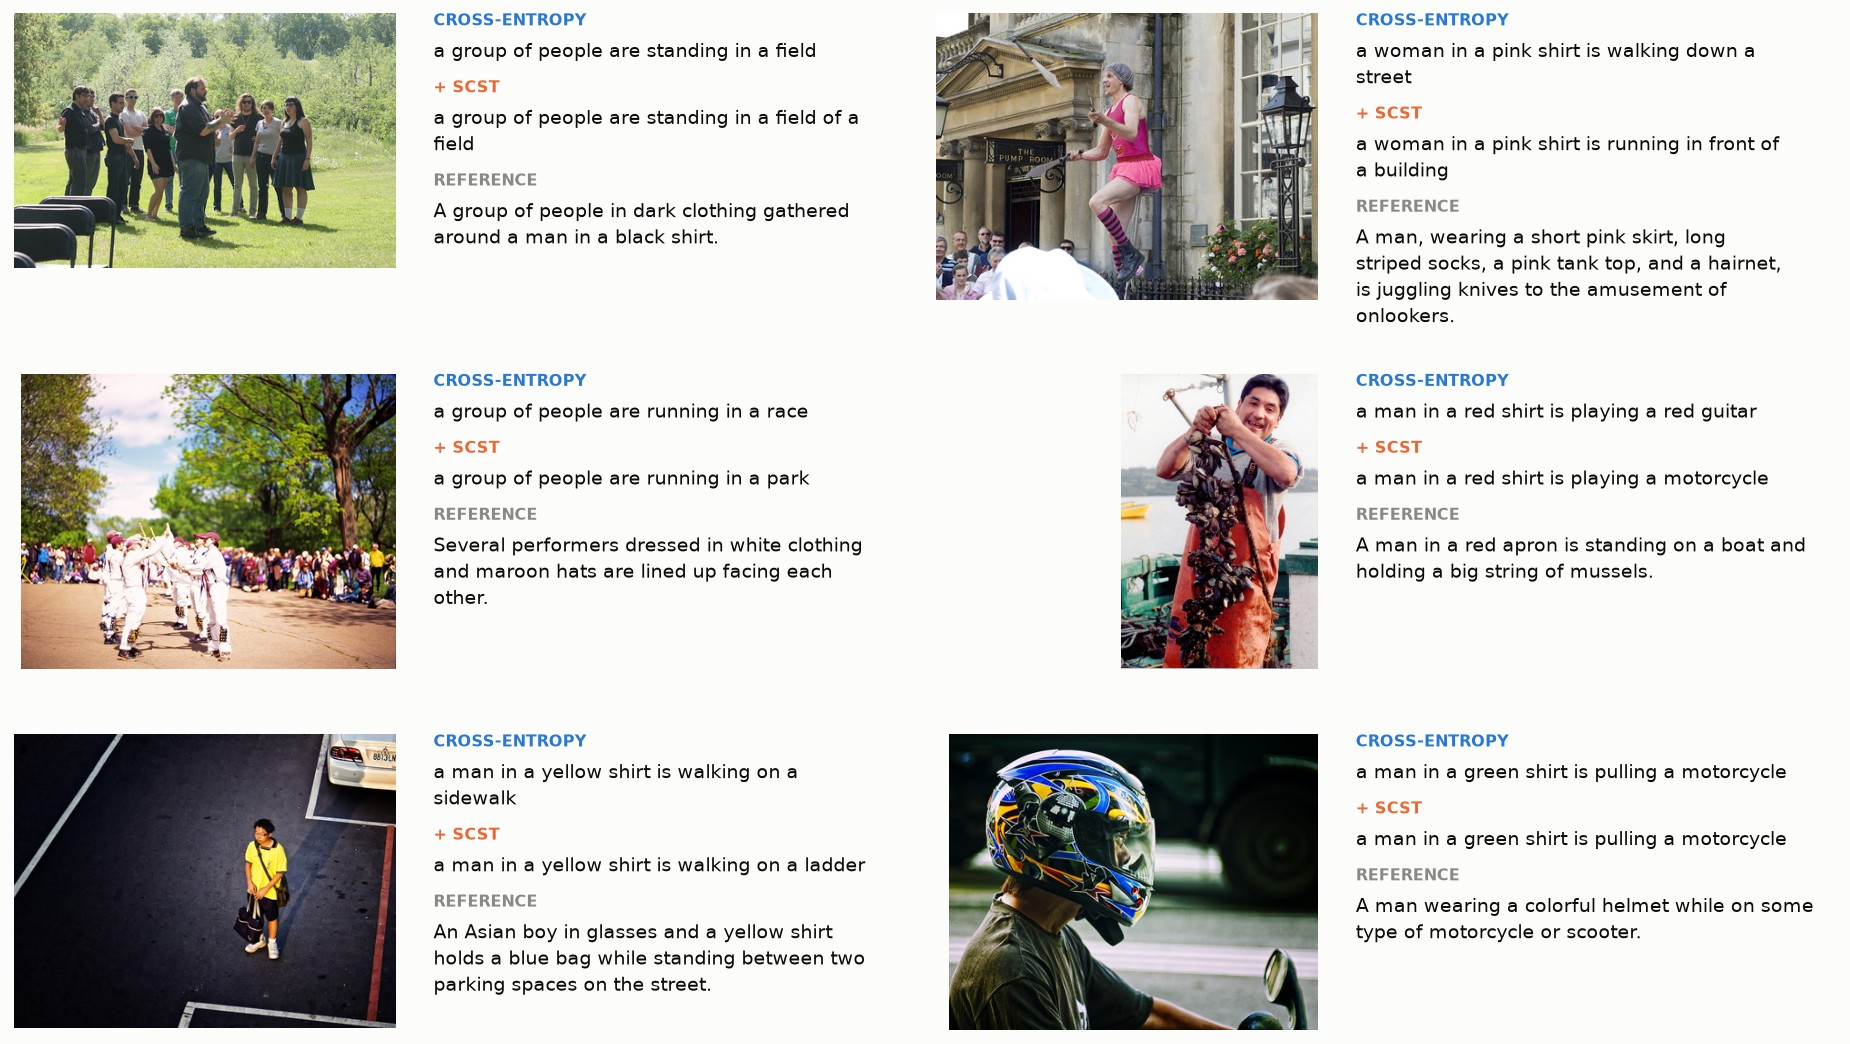

In [6]:
rng = np.random.default_rng(5)
examples = []
for img in rng.choice(val_images, 6, replace=False):
    f = img["filename"]
    examples.append({"filename": f, "captions": [
        ("cross-entropy", val_caps[("Transformer", "xe")][f]), ("+ SCST", val_caps[("Transformer", "scst")][f]),
        ("reference", rng.choice(img["captions"]))]})
viz.show_captions(examples, IMAGE_DIR, colors={"cross-entropy": viz.SERIES[0], "+ SCST": viz.SERIES[1], "reference": viz.INK_3})

## Summary

- The CIDEr-D reward matches `pycocoevalcap` to 6 decimals.
- **Biggest single improvement in the project**: Transformer val CIDEr **0.476 → 0.559 (+17.4%)**, LSTM **0.463 → 0.548 (+18.4%)**.
- Most of it arrives in the first few epochs; the training reward keeps climbing (0.44 → 0.88) while val CIDEr plateaus.
- Captions converge on high-reward phrasing: vocabulary drops from 569 to 396 words (Transformer) and 616 to 417 (LSTM), while mid-phrase endings stay at 0%.